In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Get Data
tickers = ["AAPL", "MSFT", "GOOG", "NVDA", 
            "JPM", "BAC", "GS", "WFC",
           "XOM", "CVX", "COP",
           "WMT", "JNJ", "TGT", "AMZN"]
data = yf.download(tickers, start = "2022-01-01", end = "2026-01-01")["Close"]
daily_returns = data.pct_change().dropna()

C:\Users\sidva\AppData\Local\Temp\ipykernel_15276\3119602282.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = "2022-01-01", end = "2026-01-01")["Close"]
[*********************100%***********************]  15 of 15 completed


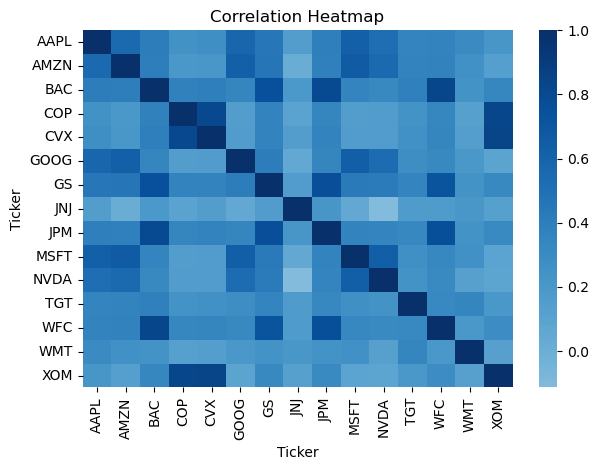

In [3]:
#Correlation Heatmap
corr = daily_returns.corr()
sns.heatmap(corr, center = 0, cmap = "Blues")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [4]:
#Scaling to prevent PC's from reflecting the highest variance
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(daily_returns)
pca = PCA()
pca.fit(scaled_returns)
#Eigenvalues = variance explained by each PC
eigenvalues = pca.explained_variance_
#Explained variance ratio
explained_var_ratio = pca.explained_variance_ratio_
#Cumulative Variance
cumulative_var = np.cumsum(explained_var_ratio)
components = [f"PC{i+1}" for i in range (len(eigenvalues))]

results_df = pd.DataFrame({"Components" : components, 
                          "Eigenvalues":eigenvalues,
                          "Explained Variance %": explained_var_ratio * 100,
                          "Cumulative Variance %": cumulative_var * 100})
print(results_df.round(2))                                                  

   Components  Eigenvalues  Explained Variance %  Cumulative Variance %
0         PC1         6.02                 40.09                  40.09
1         PC2         2.35                 15.65                  55.74
2         PC3         1.49                  9.90                  65.64
3         PC4         1.20                  8.01                  73.65
4         PC5         0.82                  5.43                  79.08
5         PC6         0.63                  4.21                  83.29
6         PC7         0.46                  3.06                  86.35
7         PC8         0.42                  2.80                  89.15
8         PC9         0.36                  2.39                  91.54
9        PC10         0.29                  1.93                  93.47
10       PC11         0.27                  1.82                  95.29
11       PC12         0.22                  1.46                  96.75
12       PC13         0.19                  1.24                

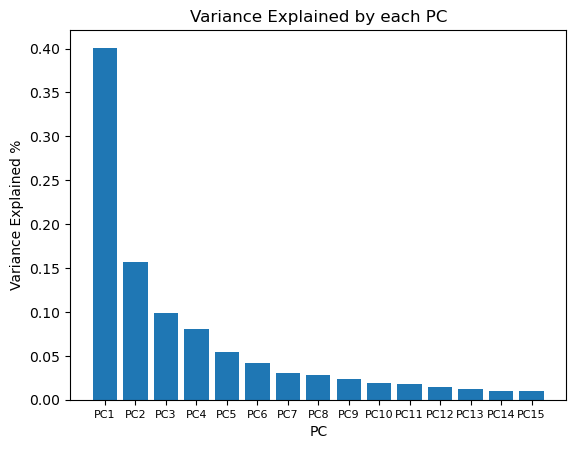

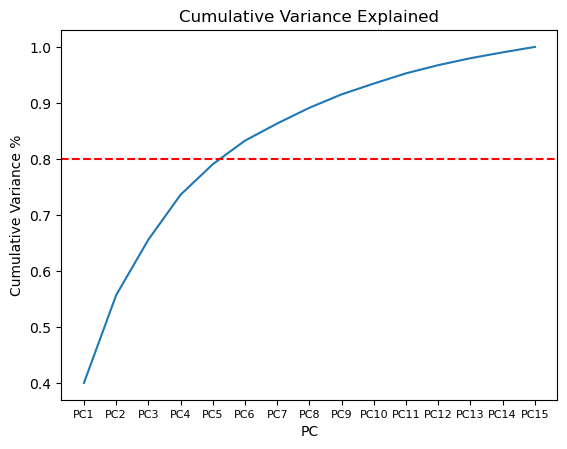

In [5]:
#Visualization
#Top Graph(Components & Explained Variance pdf)
plt.bar(components, explained_var_ratio)
plt.xlabel("PC")
plt.xticks(fontsize = 8)
plt.ylabel("Variance Explained %")
plt.title("Variance Explained by each PC")
plt.show()

#Bottom Graph(Components & Cumulative Variance cdf)
plt.plot(components, cumulative_var)
plt.axhline(0.8, color = "red", linestyle = "--")
plt.xlabel("PC")
plt.xticks(fontsize = 8)
plt.ylabel("Cumulative Variance %")
plt.title("Cumulative Variance Explained")
plt.show()

In [6]:
#Kaiser Criterion: Only keeps PC's w/ eigenvalues > 1
#Captures the most important PC's
def filter_eigenvalues(components):
    selected_eigenvalues = []
    for eigenvalue in components:
        if eigenvalue >= 1:
            selected_eigenvalues.append(eigenvalue)
    return selected_eigenvalues

kaiser_components = filter_eigenvalues(eigenvalues)
print(f"Eigenvalues > 1: {kaiser_components}")

Eigenvalues > 1: [np.float64(6.019917753722853), np.float64(2.349714143163701), np.float64(1.486229700453495), np.float64(1.2022367498676738)]


In [7]:
#Factor Loadings
eigenvectors = pca.components_
PC_names = [f"PC{i+1}" for i in range(len(eigenvalues))]
transposed_eigenvectors = pd.DataFrame(eigenvectors.T, 
                                       columns = PC_names, 
                                       index = tickers)
#Adjust Loadings
loadings = transposed_eigenvectors * np.sqrt(eigenvalues)
print(loadings)

           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
AAPL  0.698983 -0.301937 -0.220694  0.165842  0.150555  0.015756  0.077662   
MSFT  0.686295 -0.415304 -0.229894  0.015491 -0.030348  0.045642 -0.247543   
GOOG  0.803003  0.121450  0.425172 -0.167192 -0.049086 -0.004688 -0.059836   
NVDA  0.560565  0.653991 -0.364024 -0.041204 -0.008499 -0.011830 -0.003338   
JPM   0.577060  0.656467 -0.348026 -0.000817  0.020214 -0.000399 -0.001360   
BAC   0.630990 -0.451900 -0.250066  0.014643  0.165052  0.052558 -0.374748   
GS    0.813413  0.021064  0.312133 -0.182776 -0.001977 -0.049567  0.037373   
WFC   0.215042  0.188734  0.317991  0.607466  0.629741  0.126719  0.104304   
XOM   0.784025  0.087308  0.427323 -0.171485  0.019504 -0.061899  0.038097   
CVX   0.662646 -0.490457 -0.267984  0.019165  0.145550 -0.088680  0.076529   
COP   0.597221 -0.445092 -0.283543 -0.231701 -0.016455 -0.010146  0.470432   
WMT   0.527461 -0.019593  0.062156  0.412778 -0.460704  0.569882

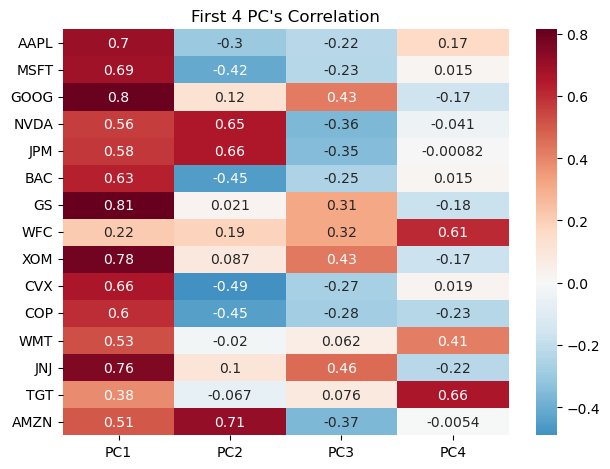

In [8]:
#Visualize Loadings
#PC1 = Beta(Market Factor)
#PC2 = Growth vs Value Stocks
#PC3 = Consumer Sector
#PC4 = Unclear (Maybe Energy Sector)
loadings_subset = loadings.iloc[:,:4]
sns.heatmap(loadings_subset, center = 0, annot = True, cmap = "RdBu_r")
plt.title("First 4 PC's Correlation")
plt.tight_layout()
plt.show()

In [9]:
#Monte Carlo Simulation
results = []
for i in range(1000):
    bootstrap_sample = daily_returns.sample(frac = 1, replace = True)
    
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(bootstrap_sample)
    
    pca = PCA()
    pca.fit(scaled_data)
    eigenvalues = pca.explained_variance_

    results.append(eigenvalues)

results_df = pd.DataFrame(results)

        Mean  5th Percentile  95th Percentile
0   6.028124        5.584645         6.500822
1   2.360291        2.177993         2.542250
2   1.491684        1.360626         1.617189
3   1.194458        1.105495         1.292360
4   0.818449        0.758391         0.876043
5   0.628656        0.561384         0.697106
6   0.470036        0.424375         0.517775
7   0.418045        0.368690         0.465420
8   0.355805        0.316411         0.395543
9   0.294820        0.260043         0.330301
10  0.263325        0.232501         0.293762
11  0.217270        0.185497         0.251425
12  0.181525        0.159988         0.206007
13  0.154904        0.138452         0.173150
14  0.137594        0.122299         0.151726


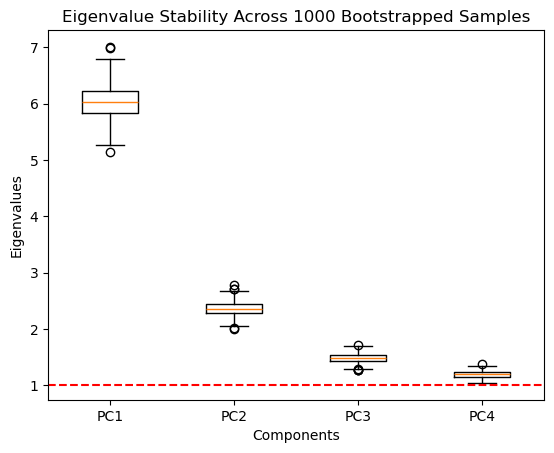

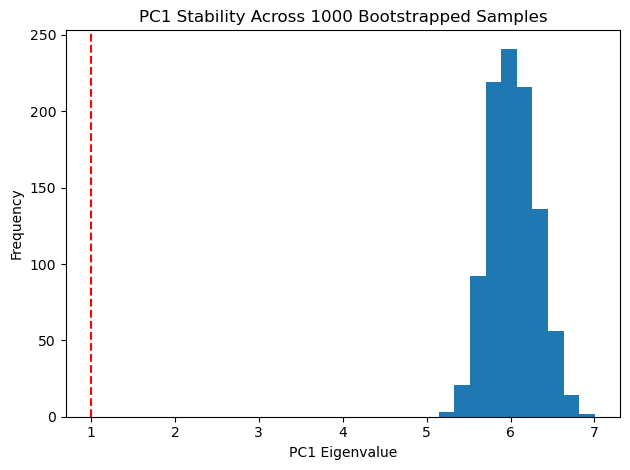

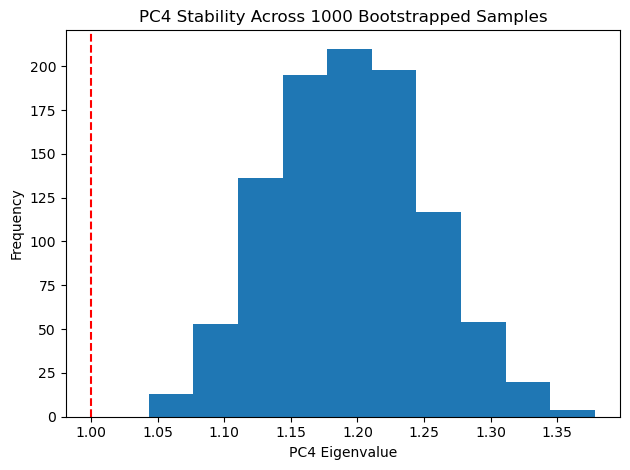

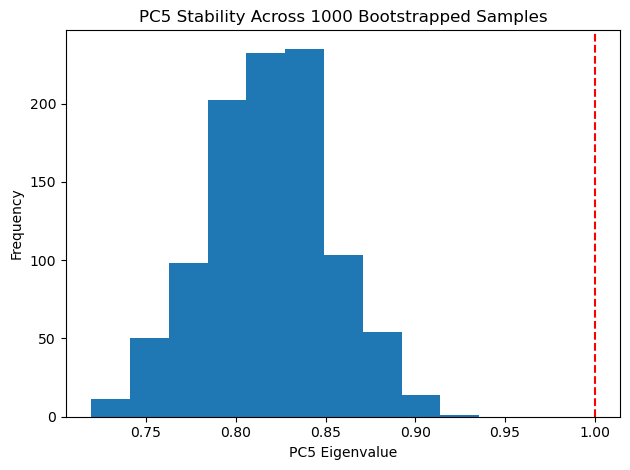

In [13]:
#Summary Statistics
#Mean
bootstrapped_mean = results_df.mean()
#5th Percentile
fifth_percentile = results_df.quantile(0.05)
#95th Percentile
ninetyfifth_percentile = results_df.quantile(0.95)
summary = pd.DataFrame({"Mean": bootstrapped_mean,
                        "5th Percentile": fifth_percentile,
                        "95th Percentile": ninetyfifth_percentile})
print(summary.iloc[:, :4])
                        

#All Eigenvalue Stability
PCs = results_df.iloc[:, :4]
plt.boxplot(PCs)
plt.title("Eigenvalue Stability Across 1000 Bootstrapped Samples")
plt.xlabel("Components")
plt.xticks([1,2,3,4], ["PC1", "PC2", "PC3", "PC4"])
plt.ylabel("Eigenvalues")
plt.axhline(1, linestyle = "--", color = "red")
plt.show()

#PC1 Stability
PC1 = results_df.iloc[:, :1]
plt.hist(PC1)
plt.title("PC1 Stability Across 1000 Bootstrapped Samples")
plt.xlabel("PC1 Eigenvalue")
plt.axvline(1, linestyle = "--", color = "red")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#PC4 Stability
PC4 = results_df.iloc[:, 3:4]
plt.hist(PC4)
plt.title("PC4 Stability Across 1000 Bootstrapped Samples")
plt.xlabel("PC4 Eigenvalue")
plt.axvline(1, linestyle = "--", color = "red")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#PC5 Stability
PC5 = results_df.iloc[:, 4:5]
plt.hist(PC5)
plt.title("PC5 Stability Across 1000 Bootstrapped Samples")
plt.xlabel("PC5 Eigenvalue")
plt.axvline(1, linestyle = "--", color = "red")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()